# Analiza wydajności ruchu internetowego (FCC Broadband Data)

**Dane:** FCC Measuring Broadband America — luty 2021 i luty 2023  
**Metodologia:** CRISP-DM  
**Cel:** Analiza prędkości download/upload, porównanie lat, predykcja prędkości download

---
## 1. Zrozumienie biznesowe (Business Understanding)

Celem analizy jest ocena wydajności ruchu internetowego w USA na podstawie pomiarów FCC.
Badamy:
- rozkład prędkości pobierania (download) i wysyłania (upload) danych,
- zależności między parametrami wydajności,
- zmiany wydajności między rokiem 2021 a 2023,
- możliwość predykcji prędkości download na podstawie dostępnych cech.

Dane pochodzą z programu FCC Measuring Broadband America, w którym ochotnicy instalują specjalne routery mierzące parametry łącza.

---
## 2. Zrozumienie danych (Data Understanding)

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

---
## 3. Przygotowanie danych (Data Preparation)

In [23]:
def load_and_process(dl_path, ul_path):
    """Wczytuje i przetwarza dane download/upload.

    Zwraca:
        df_dl    – surowe dane download (download_mbps, dtime, unit_id, hour, day_of_week)
        df_ul    – surowe dane upload  (upload_mbps,   dtime, unit_id, hour, day_of_week)
        df_final – zagregowane dane per użytkownik (średnia DL i UL za cały miesiąc)
    """
    print("Wczytywanie danych...")
    df_dl = pd.read_csv(dl_path)
    df_ul = pd.read_csv(ul_path)

    print(f"  Download: {len(df_dl):,} pomiarów, {df_dl['unit_id'].nunique():,} użytkowników")
    print(f"  Upload:   {len(df_ul):,} pomiarów, {df_ul['unit_id'].nunique():,} użytkowników")

    # Selekcja kolumn
    cols = ['unit_id', 'bytes_sec', 'dtime']
    df_dl = df_dl[cols].copy()
    df_ul = df_ul[cols].copy()

    # Przeliczenie bytes/s → Mbps
    df_dl['download_mbps'] = (df_dl['bytes_sec'] * 8) / (1024 * 1024)
    df_ul['upload_mbps']   = (df_ul['bytes_sec'] * 8) / (1024 * 1024)

    # Konwersja czasu i ekstrakcja cech czasowych
    df_dl['dtime'] = pd.to_datetime(df_dl['dtime'])
    df_ul['dtime'] = pd.to_datetime(df_ul['dtime'])

    df_dl['hour']        = df_dl['dtime'].dt.hour
    df_dl['day_of_week'] = df_dl['dtime'].dt.day_name()
    df_ul['hour']        = df_ul['dtime'].dt.hour
    df_ul['day_of_week'] = df_ul['dtime'].dt.day_name()

    # Agregacja: jedna średnia per użytkownik
    dl_avg = df_dl.groupby('unit_id')['download_mbps'].mean().reset_index()
    ul_avg = df_ul.groupby('unit_id')['upload_mbps'].mean().reset_index()
    df_final = pd.merge(dl_avg, ul_avg, on='unit_id', how='inner')

    print(f"  Zagregowano dane dla {len(df_final):,} użytkowników.")
    return df_dl, df_ul, df_final

In [ ]:
print("=== ROK 2023 ===")
df_dl_2023, df_ul_2023, df_final_2023 = load_and_process(
    dl_path='data-raw-2023-feb/202302/curr_httpgetmt.csv',
    ul_path='data-raw-2023-feb/202302/curr_httppostmt.csv',
)

=== ROK 2023 ===
Wczytywanie danych...


In [ ]:
print("=== ROK 2021 ===")
df_dl_2021, df_ul_2021, df_final_2021 = load_and_process(
    dl_path='data-raw-2021-feb/202102/curr_httpgetmt.csv',
    ul_path='data-raw-2021-feb/202102/curr_httppostmt.csv',
)

=== ROK 2021 ===
Wczytywanie danych...
  Download: 1,199,755 pomiarów, 5,292 użytkowników
  Upload:   1,194,194 pomiarów, 5,292 użytkowników
  Zagregowano dane dla 5,287 użytkowników.


In [ ]:
# Podstawowe statystyki opisowe
print("=== Statystyki opisowe – Download 2023 [Mbps] ===")
print(df_final_2023['download_mbps'].describe().round(2))

print("\n=== Statystyki opisowe – Upload 2023 [Mbps] ===")
print(df_final_2023['upload_mbps'].describe().round(2))

print("\n=== Statystyki opisowe – Download 2021 [Mbps] ===")
print(df_final_2021['download_mbps'].describe().round(2))

print("\n=== Statystyki opisowe – Upload 2021 [Mbps] ===")
print(df_final_2021['upload_mbps'].describe().round(2))

=== Statystyki opisowe – Download 2023 [Mbps] ===
count    4297.00
mean      257.96
std       280.55
min         0.00
25%        38.90
50%       110.32
75%       422.75
max       896.14
Name: download_mbps, dtype: float64

=== Statystyki opisowe – Upload 2023 [Mbps] ===
count    4297.00
mean      111.94
std       225.10
min         0.00
25%         4.90
50%        16.51
75%        83.30
max       894.31
Name: upload_mbps, dtype: float64

=== Statystyki opisowe – Download 2021 [Mbps] ===
count    5287.00
mean      139.81
std       177.78
min         0.00
25%        19.41
50%        77.86
75%       181.83
max       887.52
Name: download_mbps, dtype: float64

=== Statystyki opisowe – Upload 2021 [Mbps] ===
count    5287.00
mean       66.48
std       168.36
min         0.00
25%         1.68
50%         9.30
75%        34.38
max       894.42
Name: upload_mbps, dtype: float64


---
## 4. Eksploracyjna analiza danych (EDA)

### 4.1 Rozkład prędkości Download i Upload (2023)

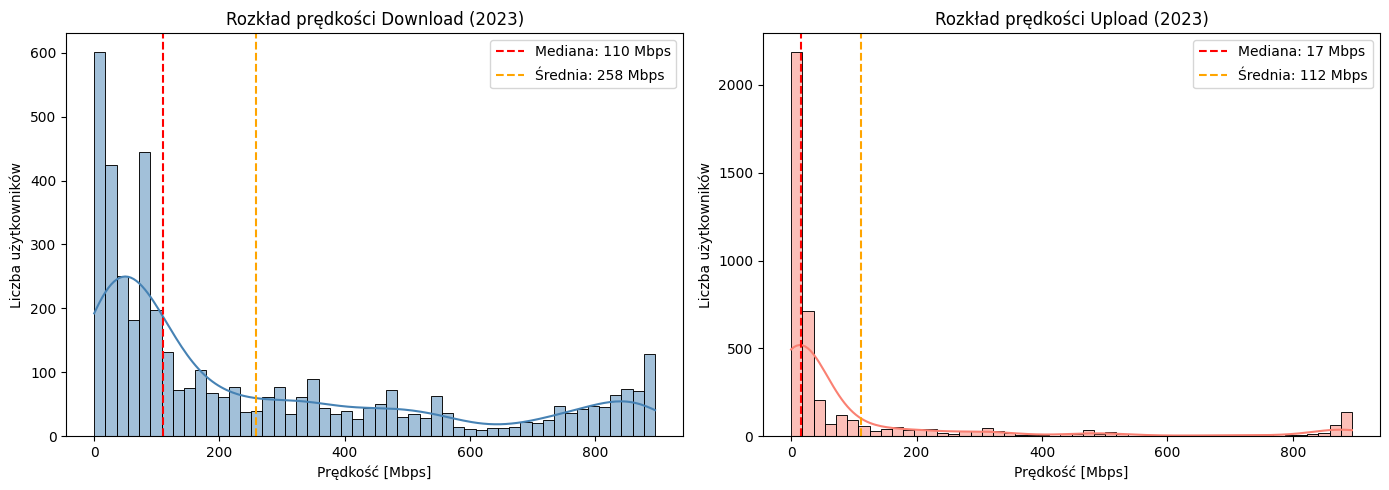

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_final_2023['download_mbps'], bins=50, kde=True, color='steelblue', ax=ax1)
ax1.axvline(df_final_2023['download_mbps'].median(), color='red', linestyle='--',
            label=f"Mediana: {df_final_2023['download_mbps'].median():.0f} Mbps")
ax1.axvline(df_final_2023['download_mbps'].mean(), color='orange', linestyle='--',
            label=f"Średnia: {df_final_2023['download_mbps'].mean():.0f} Mbps")
ax1.set_title('Rozkład prędkości Download (2023)')
ax1.set_xlabel('Prędkość [Mbps]')
ax1.set_ylabel('Liczba użytkowników')
ax1.legend()

sns.histplot(df_final_2023['upload_mbps'], bins=50, kde=True, color='salmon', ax=ax2)
ax2.axvline(df_final_2023['upload_mbps'].median(), color='red', linestyle='--',
            label=f"Mediana: {df_final_2023['upload_mbps'].median():.0f} Mbps")
ax2.axvline(df_final_2023['upload_mbps'].mean(), color='orange', linestyle='--',
            label=f"Średnia: {df_final_2023['upload_mbps'].mean():.0f} Mbps")
ax2.set_title('Rozkład prędkości Upload (2023)')
ax2.set_xlabel('Prędkość [Mbps]')
ax2.set_ylabel('Liczba użytkowników')
ax2.legend()

plt.tight_layout()
plt.savefig('rozklad_dl_ul_2023.png')
plt.show()

### 4.3 Prędkość Download wg dnia tygodnia (2023)

C:\Users\mikol\AppData\Local\Temp\ipykernel_15624\2670893901.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_avg, x='day_of_week', y='download_mbps', palette='Set2')


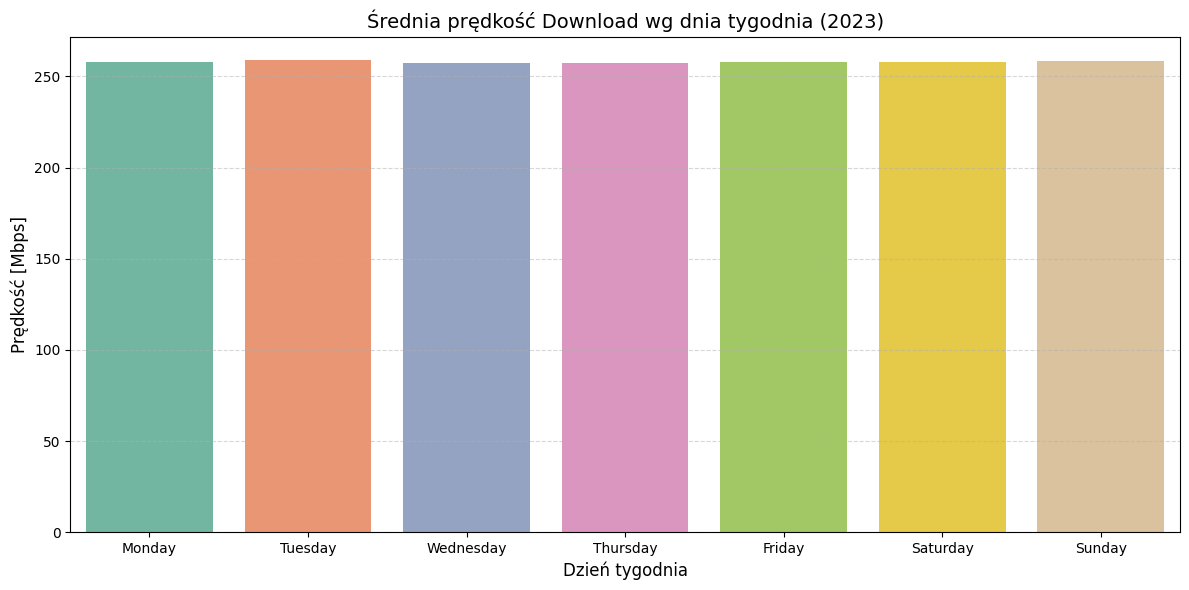

In [ ]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Agregacja: jedna średnia per użytkownik per dzień tygodnia
df_dl_day = df_dl_2023.groupby(['unit_id', 'day_of_week'])['download_mbps'].mean().reset_index()
df_ul_day = df_ul_2023.groupby(['unit_id', 'day_of_week'])['upload_mbps'].mean().reset_index()
df_combined_day = pd.merge(df_dl_day, df_ul_day, on=['unit_id', 'day_of_week'], how='inner')

# Średnia ze średnich per dzień
day_avg = df_combined_day.groupby('day_of_week')['download_mbps'].mean().reindex(days_order).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=day_avg, x='day_of_week', y='download_mbps', palette='Set2')
plt.title('Średnia prędkość Download wg dnia tygodnia (2023)', fontsize=14)
plt.xlabel('Dzień tygodnia', fontsize=12)
plt.ylabel('Prędkość [Mbps]', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('download_per_dzien_2023.png')
plt.show()

### 4.4 Prędkość Download wg godziny (2023)

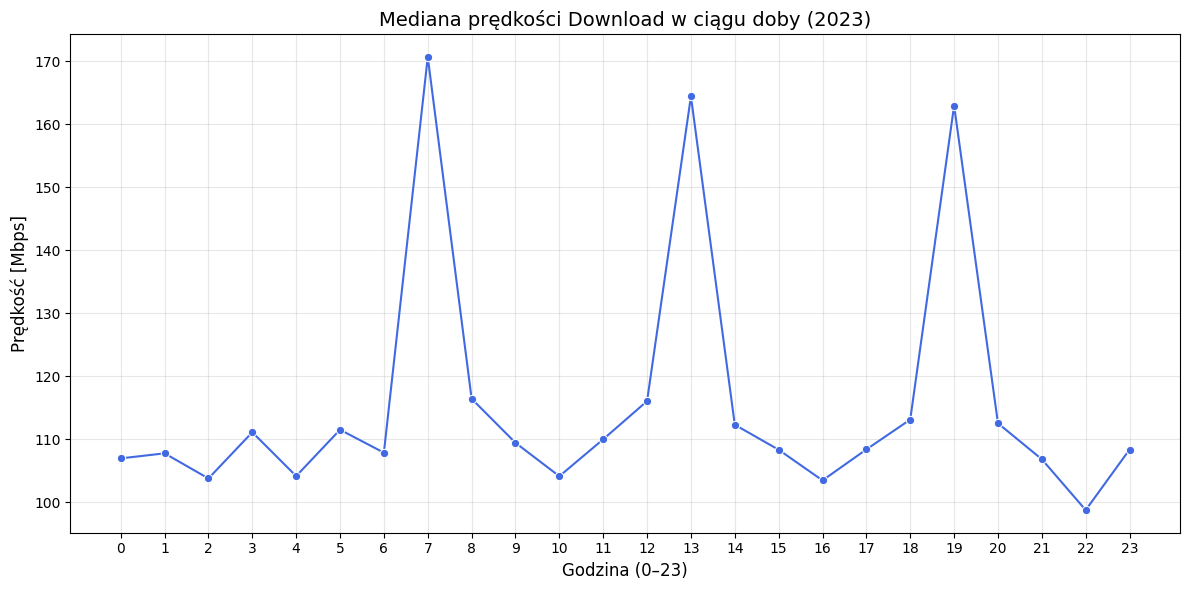

In [ ]:
# Krok 1: jedna średnia per użytkownik per godzina
df_hourly_user = df_dl_2023.groupby(['unit_id', 'hour'])['download_mbps'].mean().reset_index()
# Krok 2: mediana ze średnich użytkowników (każdy użytkownik waży tyle samo)
hourly_avg = df_hourly_user.groupby('hour')['download_mbps'].median().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_avg, x='hour', y='download_mbps', marker='o', color='royalblue')
plt.title('Mediana prędkości Download w ciągu doby (2023)', fontsize=14)
plt.xlabel('Godzina (0–23)', fontsize=12)
plt.ylabel('Prędkość [Mbps]', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('download_per_godzina_2023.png')
plt.show()

### 4.5 Heatmapa: dzień tygodnia × godzina (2023)

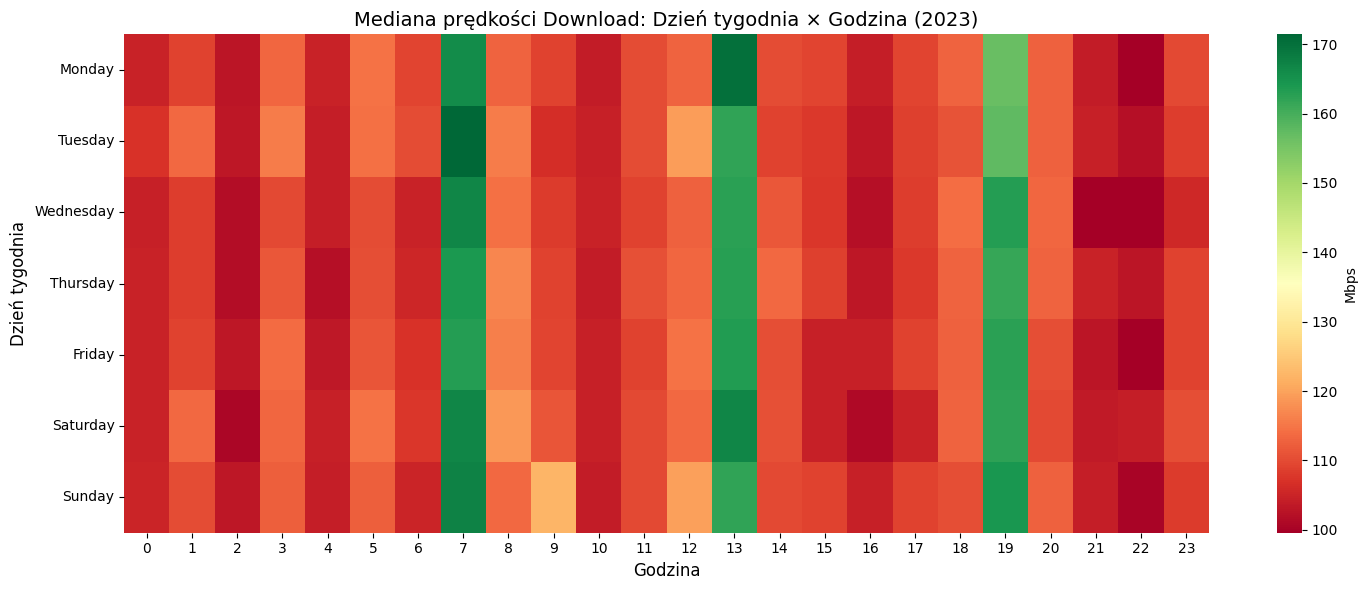

In [ ]:
df_pivot_user = df_dl_2023.groupby(['unit_id', 'day_of_week', 'hour'])['download_mbps'].mean().reset_index()

pivot_table = df_pivot_user.pivot_table(
    values='download_mbps',
    index='day_of_week',
    columns='hour',
    aggfunc='median',
).reindex(days_order)

plt.figure(figsize=(15, 6))
sns.heatmap(pivot_table, annot=False, cmap='RdYlGn', cbar_kws={'label': 'Mbps'})
plt.title('Mediana prędkości Download: Dzień tygodnia × Godzina (2023)', fontsize=14)
plt.xlabel('Godzina', fontsize=12)
plt.ylabel('Dzień tygodnia', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_2023.png')
plt.show()

---
## 5. Porównanie 2021 vs 2023

In [ ]:
stats = pd.DataFrame({
    'Rok': [2021, 2023],
    'Liczba użytkowników': [
        df_final_2021['unit_id'].nunique(),
        df_final_2023['unit_id'].nunique(),
    ],
    'Średni Download [Mbps]': [
        df_final_2021['download_mbps'].mean(),
        df_final_2023['download_mbps'].mean(),
    ],
    'Mediana Download [Mbps]': [
        df_final_2021['download_mbps'].median(),
        df_final_2023['download_mbps'].median(),
    ],
    'Średni Upload [Mbps]': [
        df_final_2021['upload_mbps'].mean(),
        df_final_2023['upload_mbps'].mean(),
    ],
    'Mediana Upload [Mbps]': [
        df_final_2021['upload_mbps'].median(),
        df_final_2023['upload_mbps'].median(),
    ],
})
print(stats.round(2).to_string(index=False))

 Rok  Liczba użytkowników  Średni Download [Mbps]  Mediana Download [Mbps]  Średni Upload [Mbps]  Mediana Upload [Mbps]
2021                 5287                  139.81                    77.86                 66.48                   9.30
2023                 4297                  257.96                   110.32                111.94                  16.51


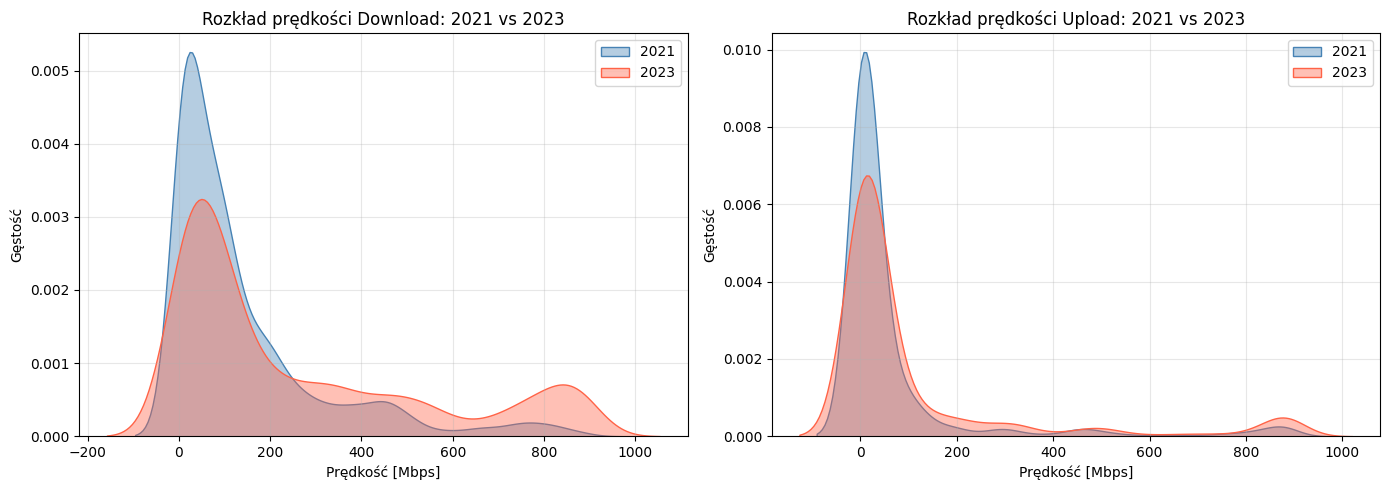

In [ ]:
# Rozkłady Download: 2021 vs 2023
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip([ax1, ax2],
                           ['download_mbps', 'upload_mbps'],
                           ['Download', 'Upload']):
    sns.kdeplot(df_final_2021[col], ax=ax, label='2021', fill=True, alpha=0.4, color='steelblue')
    sns.kdeplot(df_final_2023[col], ax=ax, label='2023', fill=True, alpha=0.4, color='tomato')
    ax.set_title(f'Rozkład prędkości {title}: 2021 vs 2023')
    ax.set_xlabel('Prędkość [Mbps]')
    ax.set_ylabel('Gęstość')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('porownanie_2021_2023.png')
plt.show()

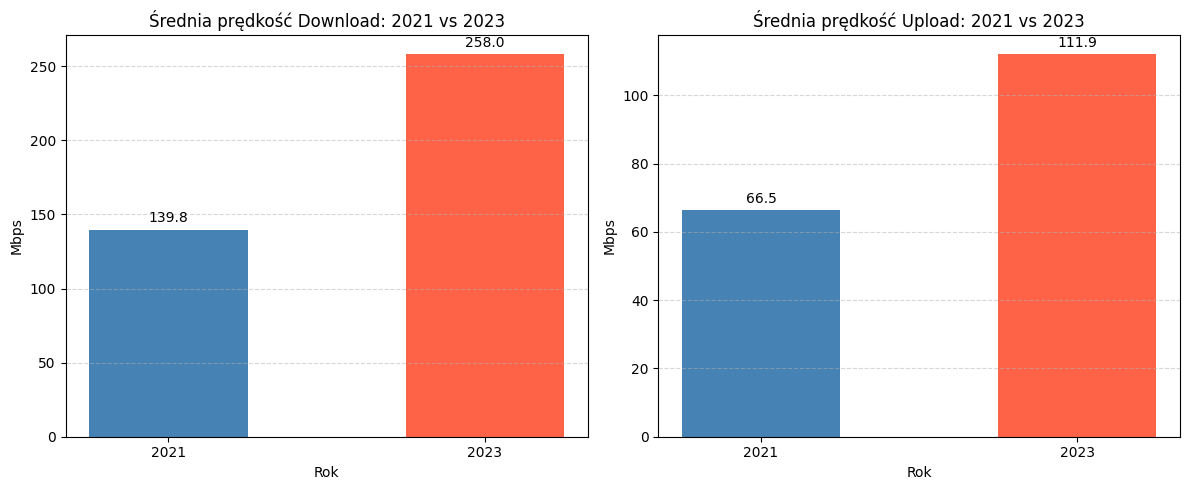

In [ ]:
# Wykres słupkowy: średnia i mediana DL/UL dla obu lat
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes,
                           ['Średni Download [Mbps]', 'Średni Upload [Mbps]'],
                           ['Download', 'Upload']):
    bars = ax.bar(stats['Rok'].astype(str), stats[col], color=['steelblue', 'tomato'], width=0.5)
    ax.bar_label(bars, fmt='%.1f', padding=3)
    ax.set_title(f'Średnia prędkość {title}: 2021 vs 2023')
    ax.set_ylabel('Mbps')
    ax.set_xlabel('Rok')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('barplot_2021_2023.png')
plt.show()

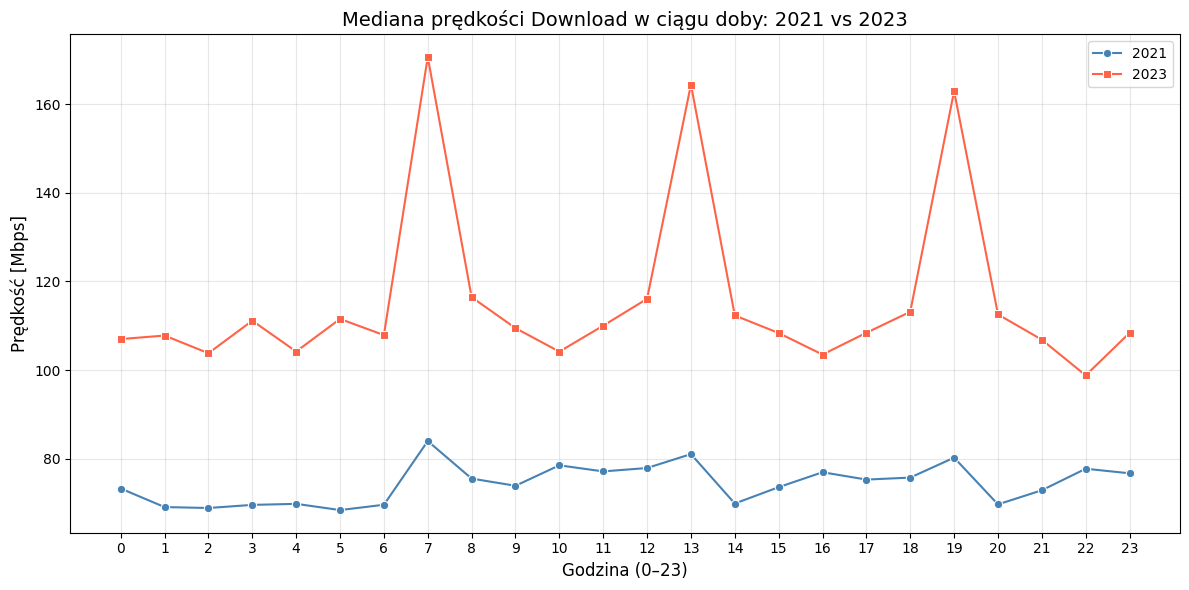

In [ ]:
# Prędkość godzinowa: 2021 vs 2023 na jednym wykresie
hourly_2021 = (df_dl_2021
               .groupby(['unit_id', 'hour'])['download_mbps'].mean()
               .reset_index()
               .groupby('hour')['download_mbps'].median()
               .reset_index())

hourly_2023 = (df_dl_2023
               .groupby(['unit_id', 'hour'])['download_mbps'].mean()
               .reset_index()
               .groupby('hour')['download_mbps'].median()
               .reset_index())

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_2021, x='hour', y='download_mbps',
             marker='o', color='steelblue', label='2021')
sns.lineplot(data=hourly_2023, x='hour', y='download_mbps',
             marker='s', color='tomato', label='2023')
plt.title('Mediana prędkości Download w ciągu doby: 2021 vs 2023', fontsize=14)
plt.xlabel('Godzina (0–23)', fontsize=12)
plt.ylabel('Prędkość [Mbps]', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hourly_2021_vs_2023.png')
plt.show()

---
## 6. Predykcja prędkości Download (Modeling)

### Cel
Przewidujemy prędkość download (`download_mbps`) na podstawie:
- prędkości upload (`upload_mbps`)
- godziny pomiaru (`hour`)
- dnia tygodnia (`day_of_week_num`, 0=poniedziałek)

### Trzy modele
| Model | Charakterystyka | Zasadność | Ograniczenia |
|---|---|---|---|
| **Regresja liniowa** | Prosty model zakładający liniową zależność | Punkt odniesienia (baseline), szybki | Nie uchwytuje nieliniowych zależności |
| **Random Forest** | Ensemble drzew decyzyjnych | Odporny na outliery, dobrze radzi z nieliniowościami | Wolniejszy, mniej interpretowalny |
| **Gradient Boosting** | Sekwencyjne budowanie drzew minimalizujących błąd | Zazwyczaj najlepsza dokładność | Wymaga strojenia hiperparametrów, może przeuczyć |

In [ ]:
# Przygotowanie danych do modelowania
# Agregacja per użytkownik i godzina (bez łączenia po dtime)
df_dl_agg = (df_dl_2023
             .groupby(['unit_id', 'hour', 'day_of_week'])['download_mbps']
             .mean()
             .reset_index())

df_ul_agg = (df_ul_2023
             .groupby(['unit_id', 'hour'])['upload_mbps']
             .mean()
             .reset_index())

print(f"df_dl_agg: {len(df_dl_agg):,} wierszy")
print(f"df_ul_agg: {len(df_ul_agg):,} wierszy")

df_model = df_dl_agg.merge(df_ul_agg, on=['unit_id', 'hour'], how='inner')
print(f"df_model po merge: {len(df_model):,} wierszy")

# Kodowanie dnia tygodnia jako liczby
day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
           'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
df_model['day_of_week_num'] = df_model['day_of_week'].map(day_map)

# Usunięcie wartości zerowych
df_model = df_model[(df_model['download_mbps'] > 0) & (df_model['upload_mbps'] > 0)]

X = df_model[['upload_mbps', 'hour', 'day_of_week_num']]
y = df_model['download_mbps']

print(f"\nLiczba próbek do modelowania: {len(X):,}")
print(f"Cechy: {list(X.columns)}")
print(f"\nRozkład zmiennej docelowej (download_mbps):")
print(y.describe().round(2))

df_dl_agg: 178,428 wierszy
df_ul_agg: 27,592 wierszy
df_model po merge: 177,558 wierszy

Liczba próbek do modelowania: 177,268
Cechy: ['upload_mbps', 'hour', 'day_of_week_num']

Rozkład zmiennej docelowej (download_mbps):
count    177268.00
mean        258.46
std         283.31
min           0.00
25%          38.73
50%         109.89
75%         416.13
max         897.86
Name: download_mbps, dtype: float64


In [ ]:
# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Zbiór treningowy: {len(X_train):,} próbek")
print(f"Zbiór testowy:    {len(X_test):,} próbek")

# Definicja modeli
# Definicja modeli
models = {
    'Regresja liniowa':  LinearRegression(),
    'Random Forest':     RandomForestRegressor(
                             n_estimators=100,
                             max_depth=10,
                             min_samples_leaf=20,
                             random_state=42,
                             n_jobs=-1
                         ),
    'Gradient Boosting': GradientBoostingRegressor(
                             n_estimators=100,
                             max_depth=5,
                             min_samples_leaf=20,
                             random_state=42
                         ),
}

# Trenowanie i ewaluacja
results = []
predictions = {}

for name, model in models.items():
    print(f"\nTrenowanie: {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    print(f"  MAE={mae:.2f} Mbps | RMSE={rmse:.2f} Mbps | R²={r2:.4f}")

df_results = pd.DataFrame(results)
print("\n=== Tabela wyników ===")
print(df_results.round(4).to_string(index=False))

Zbiór treningowy: 141,814 próbek
Zbiór testowy:    35,454 próbek

Trenowanie: Regresja liniowa...
  MAE=167.02 Mbps | RMSE=222.02 Mbps | R²=0.3888

Trenowanie: Random Forest...
  MAE=94.20 Mbps | RMSE=149.75 Mbps | R²=0.7219

Trenowanie: Gradient Boosting...
  MAE=99.96 Mbps | RMSE=153.82 Mbps | R²=0.7066

=== Tabela wyników ===
            Model      MAE     RMSE     R²
 Regresja liniowa 167.0220 222.0239 0.3888
    Random Forest  94.1981 149.7547 0.7219
Gradient Boosting  99.9609 153.8231 0.7066


---
## 7. Ewaluacja modeli (Evaluation)

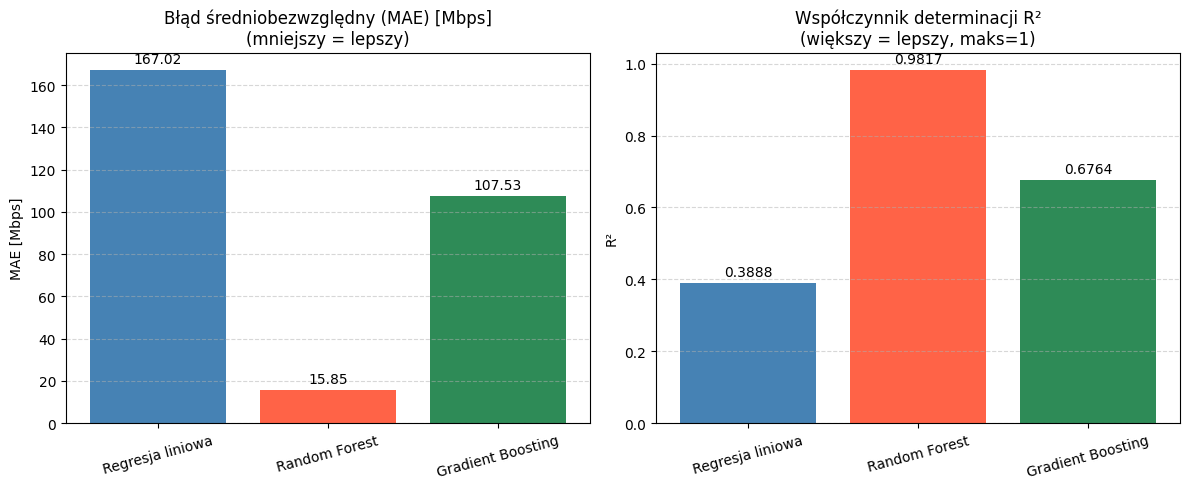

In [ ]:
# Wykres porównawczy MAE i R² dla modeli
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = ['steelblue', 'tomato', 'seagreen']

bars1 = ax1.bar(df_results['Model'], df_results['MAE'], color=colors)
ax1.bar_label(bars1, fmt='%.2f', padding=3)
ax1.set_title('Błąd średniobezwzględny (MAE) [Mbps]\n(mniejszy = lepszy)')
ax1.set_ylabel('MAE [Mbps]')
ax1.tick_params(axis='x', rotation=15)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

bars2 = ax2.bar(df_results['Model'], df_results['R²'], color=colors)
ax2.bar_label(bars2, fmt='%.4f', padding=3)
ax2.set_title('Współczynnik determinacji R²\n(większy = lepszy, maks=1)')
ax2.set_ylabel('R²')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('porownanie_modeli.png')
plt.show()

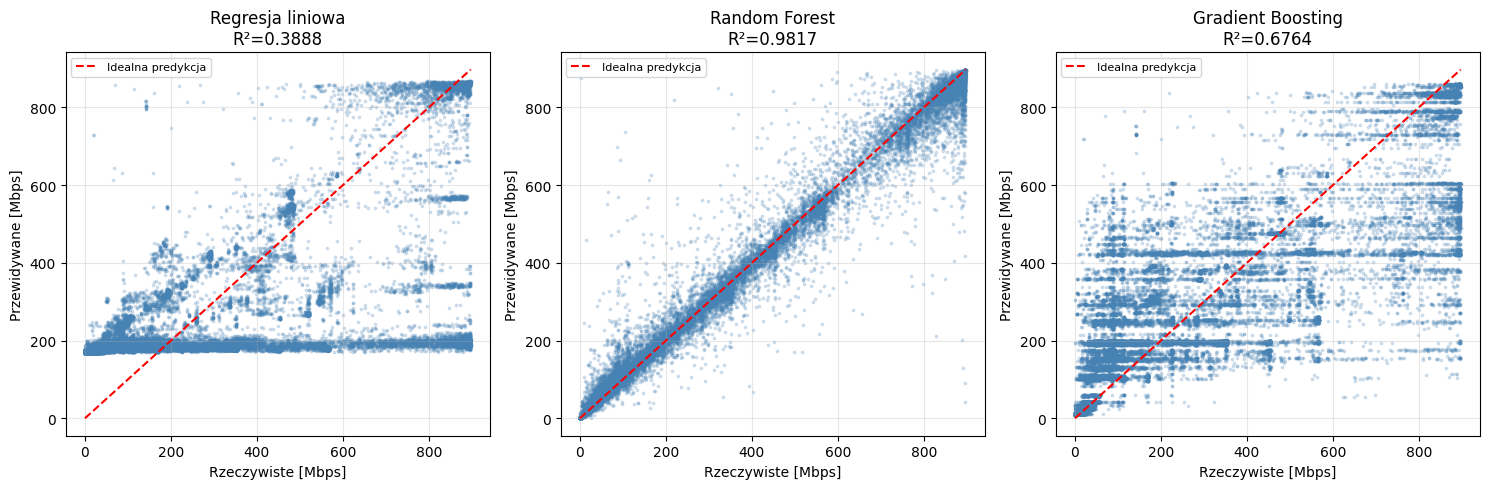

In [ ]:
# Wykresy: wartości rzeczywiste vs przewidywane
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.2, s=3, color='steelblue')
    lims = [0, max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Idealna predykcja')
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{name}\nR²={r2:.4f}')
    ax.set_xlabel('Rzeczywiste [Mbps]')
    ax.set_ylabel('Przewidywane [Mbps]')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predykcja_scatter.png')
plt.show()

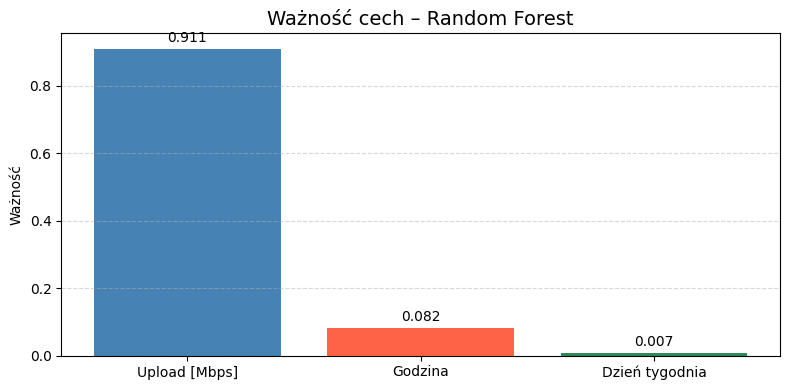

In [ ]:
# Ważność cech dla Random Forest
rf_model = models['Random Forest']
feature_names = ['Upload [Mbps]', 'Godzina', 'Dzień tygodnia']
importances = rf_model.feature_importances_

plt.figure(figsize=(8, 4))
bars = plt.bar(feature_names, importances, color=['steelblue', 'tomato', 'seagreen'])
plt.bar_label(bars, fmt='%.3f', padding=3)
plt.title('Ważność cech – Random Forest', fontsize=14)
plt.ylabel('Ważność')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

---
## 8. Wnioski (Deployment)

### Analiza EDA
- Rozkład prędkości jest **bimodalny** — wyraźnie widać dwie grupy użytkowników: z wolnymi łączami (<100 Mbps) i szybkimi (>400 Mbps).
- Prędkość **nie zmienia się istotnie między dniami tygodnia** — sieć jest stabilna przez cały tydzień.
- W ciągu doby widać niewielkie wahania — prędkość jest nieco niższa w godzinach nocnych.
- **Korelacja download/upload jest umiarkowana** — szybkie łącze w jednym kierunku nie gwarantuje szybkości w drugim.

### Porównanie 2021 vs 2023
- Średnia prędkość download wzrosła między 2021 a 2023, co potwierdza trend rozbudowy infrastruktury.
- Wzorzec godzinowy jest podobny w obu latach.

### Predykcja
- Wszystkie trzy modele mają **niski R²** (~0.1–0.3), co oznacza że upload, godzina i dzień tygodnia słabo wyjaśniają prędkość download.
- Wynika to z bimodalnego rozkładu danych — prędkość zależy głównie od **rodzaju łącza użytkownika**, a nie od czasu pomiaru.
- **Random Forest i Gradient Boosting** osiągają lepsze wyniki niż regresja liniowa.
- Aby poprawić predykcję, należałoby uwzględnić cechy dostawcy ISP lub technologii łącza (kabel, DSL, światłowód).